# AFFC-Net + SUARA2: BreaKHis Full Experiment Notebook (v5)

This notebook is the **exact BreaKHis equivalent** of the LC25000 v5 notebook.

**Dataset:** BreaKHis — 7,909 histopathology images, binary classification (Benign=0, Malignant=1)  
**Base paper:** AFFC-Net (Adaptive Feature Fusion with Cross-attention)  
**Novelty:** SUARA2 — 2-D process-grid allreduce for distributed training speedup

Covers:
1. SUARA2 theoretical cost models (same Hockney parameters, updated message size for BreaKHis model)
2. Theoretical speedup table & plots
3. Training commands (uses `train_affcnet_suara_breakhis_v5.py`)
4. Load & display results: classification metrics + training efficiency
5. Comparison charts: AFFC-Net (native) vs AFFC-Net + SUARA2

In [1]:
import os, sys, math, json, time
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt

HOME = os.path.expanduser('~')

# Gradient message size — auto-updated from results JSON after first run.
# BreaKHis model has same architecture as LC25000 but num_classes=2 vs 5,
# so grad buffer is slightly smaller. Estimate: ~2.49 MB.
MS_BYTES = 2_490_000   # ~2.49 MB estimate (updated after first run below)

print(f'Setup done. HOME = {HOME}')
print(f'Gradient message size estimate: {MS_BYTES/1024:.1f} KB')

Setup done. HOME = /nfsshare/users/P126003189
Gradient message size estimate: 2431.6 KB


## 1. SUARA2 Theoretical Cost Models

Same Hockney parameters as the SUARA2 paper (Shaheen-II cluster). Only the gradient message size changes to match the BreaKHis AFFC-Net model.

In [3]:
def T_linear(P, m, a, b, g): return (P-1) * (2*(a + b*m) + g*m)
def T_nono(P, m, a, b, g):   return 2*(P-1)*a + 2*b*m*math.log2(P) + g*m*(P-1)/P
def T_rd(P, m, a, b, g):     return math.log2(P)*(a + b*m + g*m) if P > 1 else 0.0
def T_rnos(P, m, a, b, g):   return 2*(P-1)*a + 2*((P-1)/P)*b*m + ((P-1)/P)*g*m
def T_rab(P, m, a, b, g):    return (2*math.log2(P)*a + 2*((P-1)/P)*b*m + ((P-1)/P)*g*m) if P > 1 else 0.0

ALGO_FUNCS = {'linear': T_linear, 'nono': T_nono, 'rd': T_rd, 'rnos': T_rnos, 'rab': T_rab}

# Hockney model parameters (Shaheen-II, from SUARA2 paper)
H_PARAMS = {
    'linear': (1.5e-6, 6.25e-11), 'nono': (1.5e-6, 6.25e-11),
    'rd'    : (1.2e-6, 7.0e-11),  'rnos': (1.4e-6, 6.5e-11),
    'rab'   : (1.3e-6, 6.8e-11),
}
GAMMA = 2e-10

def native_ring_time(P, m):
    #\'\'\'Native allreduce using ring (Open MPI default for large messages)\'\'\'
    a, b = H_PARAMS['rnos']
    return T_rnos(P, m, a, b, GAMMA)

def suara2_optimal_time(P, m):
    #\'\'\'SUARA2: best 2D grid, each sub-group picks its own optimal algorithm\'\'\'
    best_time = float('inf')
    best_Pc   = 1
    for Pc in range(1, P + 1):
        if P % Pc != 0:
            continue
        Pr = P // Pc
        t_row = min(f(Pc, m, *H_PARAMS[a], GAMMA) for a, f in ALGO_FUNCS.items())
        t_col = min(f(Pr, m, *H_PARAMS[a], GAMMA) for a, f in ALGO_FUNCS.items())
        ts = t_row + t_col
        if ts < best_time:
            best_time = ts
            best_Pc   = Pc
    return best_time, best_Pc

print('Allreduce models defined.')
print(f'Message size: {MS_BYTES/1e6:.3f} MB  (BreaKHis AFFC-Net gradient buffer)')

Allreduce models defined.
Message size: 2.490 MB  (BreaKHis AFFC-Net gradient buffer)


## 2. Theoretical Speedup Table

In [4]:
P_values = [2, 4, 8, 16, 32, 64, 120, 128, 256, 512, 1024]

speedup_vals  = []
t_native_vals = []
t_suara_vals  = []
Pc_vals       = []

print(f"{'P':>6}  {'T_native(ms)':>14}  {'T_SUARA2(ms)':>14}  {'Speedup':>9}  {'Pc*':>5}")
print('-' * 60)

for P in P_values:
    tn     = native_ring_time(P, MS_BYTES)
    ts, Pc = suara2_optimal_time(P, MS_BYTES)
    sp     = tn / ts if ts > 0 else 1.0
    speedup_vals.append(sp)
    t_native_vals.append(tn * 1e3)
    t_suara_vals.append(ts * 1e3)
    Pc_vals.append(Pc)
    marker = '  <-- your cluster' if P == 120 else ''
    print(f"{P:>6}  {tn*1e3:>14.3f}  {ts*1e3:>14.3f}  {sp:>9.3f}x  {Pc:>5}{marker}")

     P    T_native(ms)    T_SUARA2(ms)    Speedup    Pc*
------------------------------------------------------------
     2           0.414           0.414      1.000x      1
     4           0.625           0.625      1.000x      1
     8           0.739           0.739      1.000x      1
    16           0.812           0.795      1.022x      1
    32           0.883           0.823      1.072x      1
    64           0.985           0.839      1.174x      1
   120           1.148           0.848      1.354x      1  <-- your cluster
   128           1.171           0.848      1.380x      1
   256           1.532           0.854      1.794x      1
   512           2.251           0.858      2.622x      1
  1024           3.685           0.862      4.276x      1


## 3. Theoretical Speedup Plots

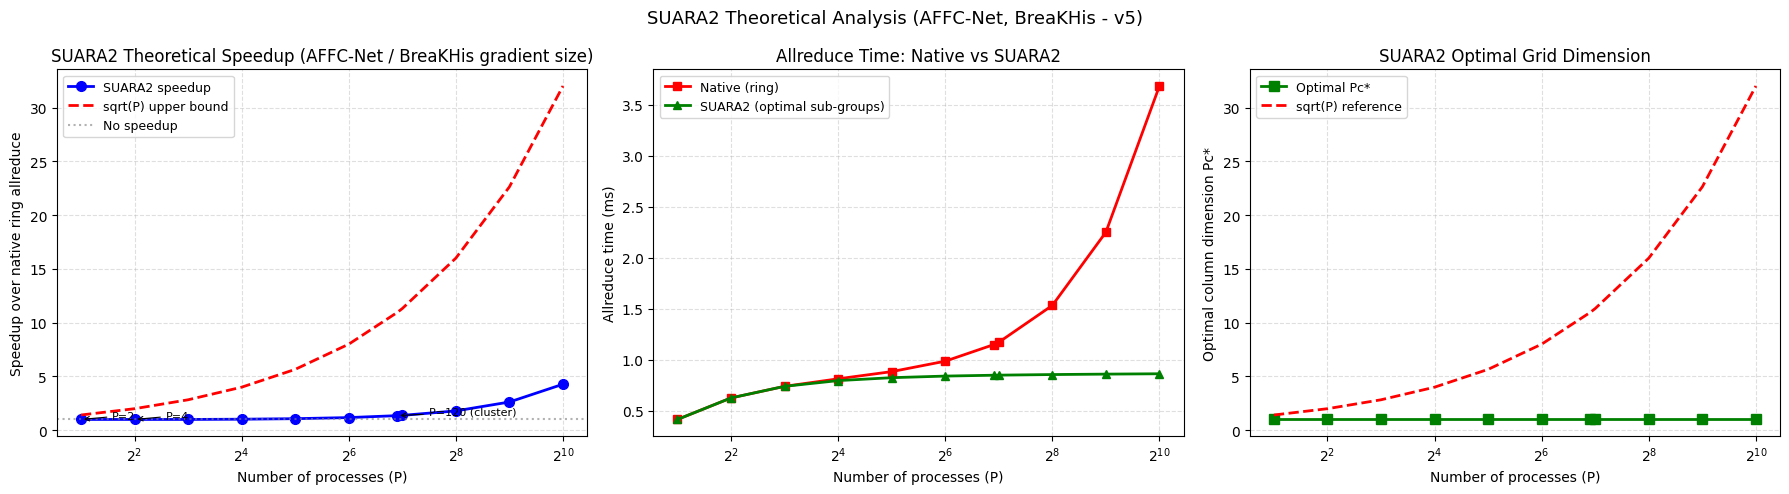

Saved -> /nfsshare/users/P126003189/breakhis_suara2_theoretical_speedup_v5.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Speedup curve
ax = axes[0]
ax.plot(P_values, speedup_vals, 'bo-', lw=2, markersize=7, label='SUARA2 speedup')
ax.plot(P_values, [math.sqrt(P) for P in P_values], 'r--', lw=2, label='sqrt(P) upper bound')
ax.axhline(1.0, color='gray', ls=':', alpha=0.6, label='No speedup')
for P_mark, label_str in [(2, 'P=2'), (4, 'P=4'), (120, 'P=120 (cluster)')]:
    if P_mark in P_values:
        idx = P_values.index(P_mark)
        ax.annotate(label_str, xy=(P_mark, speedup_vals[idx]),
                    xytext=(P_mark * 1.5, speedup_vals[idx] + 0.08),
                    fontsize=8, arrowprops=dict(arrowstyle='->', lw=0.8))
ax.set_xscale('log', base=2)
ax.set_xlabel('Number of processes (P)')
ax.set_ylabel('Speedup over native ring allreduce')
ax.set_title('SUARA2 Theoretical Speedup (AFFC-Net / BreaKHis gradient size)')
ax.legend(fontsize=9)
ax.grid(True, ls='--', alpha=0.4)

# Plot B: Allreduce times
ax = axes[1]
ax.plot(P_values, t_native_vals, 'rs-', lw=2, markersize=6, label='Native (ring)')
ax.plot(P_values, t_suara_vals,  'g^-', lw=2, markersize=6, label='SUARA2 (optimal sub-groups)')
ax.set_xscale('log', base=2)
ax.set_xlabel('Number of processes (P)')
ax.set_ylabel('Allreduce time (ms)')
ax.set_title('Allreduce Time: Native vs SUARA2')
ax.legend(fontsize=9)
ax.grid(True, ls='--', alpha=0.4)

# Plot C: Optimal Pc*
ax = axes[2]
ax.plot(P_values, Pc_vals, 'gs-', lw=2, markersize=7, label='Optimal Pc*')
ax.plot(P_values, [math.sqrt(P) for P in P_values], 'r--', lw=2, label='sqrt(P) reference')
ax.set_xscale('log', base=2)
ax.set_xlabel('Number of processes (P)')
ax.set_ylabel('Optimal column dimension Pc*')
ax.set_title('SUARA2 Optimal Grid Dimension')
ax.legend(fontsize=9)
ax.grid(True, ls='--', alpha=0.4)

plt.suptitle('SUARA2 Theoretical Analysis (AFFC-Net, BreaKHis - v5)', fontsize=13)
plt.tight_layout()
save_path = os.path.join(HOME, 'breakhis_suara2_theoretical_speedup_v5.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'Saved -> {save_path}')

## 4. Training Commands (BreaKHis v5 script)

Run these in your cluster terminal. Feature files must exist in `$HOME`:
- `breakhis_cnn_features_ver2.pt`
- `breakhis_gnn_features_ver2.pt`
- `breakhis_gnn_labels_ver2.pt`

In [6]:
# Run these in your cluster terminal using train_affcnet_suara_breakhis_v5.py
#
# P=1 baseline (no distributed)
# CUDA_VISIBLE_DEVICES=0 python ~/train_affcnet_suara_breakhis_v5.py --mode native --epochs 100 --no_dist
#
# P=2 native allreduce
# CUDA_VISIBLE_DEVICES=0,1 torchrun --nproc_per_node=2 ~/train_affcnet_suara_breakhis_v5.py --mode native --epochs 100
#
# P=4 native allreduce
# CUDA_VISIBLE_DEVICES=0,1,2,3 torchrun --nproc_per_node=4 ~/train_affcnet_suara_breakhis_v5.py --mode native --epochs 100
#
# P=2 SUARA2
# CUDA_VISIBLE_DEVICES=0,1 torchrun --nproc_per_node=2 ~/train_affcnet_suara_breakhis_v5.py --mode suara --epochs 100
#
# P=4 SUARA2
# CUDA_VISIBLE_DEVICES=0,1,2,3 torchrun --nproc_per_node=4 ~/train_affcnet_suara_breakhis_v5.py --mode suara --epochs 100

print('Commands listed. Run on the cluster, then proceed to the results cells.')

Commands listed. Run on the cluster, then proceed to the results cells.


## 5. Load Results

In [7]:
results = {}

# BreaKHis binary classification — no published paper target, leave as None
PAPER_TARGET = None

for mode in ['native', 'suara']:
    for p in [1, 2, 4]:
        for ver in ['ver5', 'ver4', 'ver3']:
            fname = os.path.join(HOME, f'breakhis_results_{ver}_{mode}_P{p}.json')
            if os.path.exists(fname):
                with open(fname) as f:
                    results[f'{mode}_P{p}'] = json.load(f)
                print(f'Loaded ({ver}): {fname}')
                break
        else:
            print(f'Missing: breakhis_results_ver5_{mode}_P{p}.json  (run training first)')

print(f'\nAvailable configs: {list(results.keys())}')

# Update MS_BYTES from actual gradient size if available
if 'native_P1' in results and 'grad_bytes' in results['native_P1']:
    MS_BYTES = results['native_P1']['grad_bytes']
    print(f'Updated MS_BYTES from results: {MS_BYTES/1024:.1f} KB')

# Show dataset split info
if 'native_P1' in results:
    r = results['native_P1']
    for k in ['total_samples', 'train_samples', 'val_samples', 'test_samples']:
        if k in r:
            print(f'  {k}: {r[k]}')

Loaded (ver5): /nfsshare/users/P126003189/breakhis_results_ver5_native_P1.json
Loaded (ver5): /nfsshare/users/P126003189/breakhis_results_ver5_native_P2.json
Loaded (ver5): /nfsshare/users/P126003189/breakhis_results_ver5_native_P4.json
Missing: breakhis_results_ver5_suara_P1.json  (run training first)
Loaded (ver5): /nfsshare/users/P126003189/breakhis_results_ver5_suara_P2.json
Loaded (ver5): /nfsshare/users/P126003189/breakhis_results_ver5_suara_P4.json

Available configs: ['native_P1', 'native_P2', 'native_P4', 'suara_P2', 'suara_P4']
Updated MS_BYTES from results: 7129.0 KB
  total_samples: 7909
  train_samples: 5536
  val_samples: 1186
  test_samples: 1187


## 6. Classification Metrics + Training Efficiency Table

In [8]:
METRIC_KEYS   = ['acc', 'prec', 'recall', 'spec', 'f1']
METRIC_LABELS = ['Acc', 'Prec', 'Rec',    'Spec', 'F1']

print('=' * 95)
print('Part A  Classification Metrics — BreaKHis (Benign vs Malignant)')
print('=' * 95)
print(f"{'Config':<30} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'Spec':>8} {'F1':>8}")
print('-' * 95)

ROWS = [
    ('AFFC-Net (native, P=1)',  'native_P1'),
    ('AFFC-Net (native, P=2)',  'native_P2'),
    ('AFFC-Net (native, P=4)',  'native_P4'),
    ('AFFC-Net + SUARA2 (P=2)', 'suara_P2'),
    ('AFFC-Net + SUARA2 (P=4)', 'suara_P4'),
]
for label, key in ROWS:
    if key in results:
        r    = results[key]
        vals = [r[f'test_{m}'] * 100 for m in METRIC_KEYS]
        print(f"{label:<30} " + '  '.join(f"{v:>7.2f}%" for v in vals))
    else:
        print(f"{label:<30}  -- not yet run")

print('=' * 95)

print()
print('=' * 65)
print('Part B  Training Efficiency  — Epoch Wall-Time')
print('=' * 65)
print(f"{'Config':<26} {'avg epoch(s)':>13} {'EP speedup':>11}")
print('-' * 52)

base_ep = results.get('native_P1', {}).get('avg_epoch_time')

for p in [1, 2, 4]:
    for mode in ['native', 'suara']:
        key = f'{mode}_P{p}'
        if p == 1 and mode == 'suara':
            continue
        if key not in results:
            continue
        r = results[key]
        ep_sp = f"{base_ep / r['avg_epoch_time']:.2f}x" if base_ep else '--'
        print(f"{key:<26} {r['avg_epoch_time']:>13.2f} {ep_sp:>11}")

print('=' * 65)
print('  EP speedup: relative to native P=1 baseline')

print()
print('=' * 65)
print('Part C  Allreduce Timing (comms only)')
print('=' * 65)
print(f"{'Config':<26} {'avg AR(s)':>10} {'AR speedup':>12}")
print('-' * 50)

base_ar = results.get('native_P2', {}).get('avg_ar_time')
for p in [2, 4]:
    for mode in ['native', 'suara']:
        key = f'{mode}_P{p}'
        if key not in results:
            continue
        r = results[key]
        ar = r.get('avg_ar_time', 0)
        ar_sp = f"{base_ar / ar:.2f}x" if base_ar and ar else '--'
        print(f"{key:<26} {ar:>10.4f} {ar_sp:>12}")
print('=' * 65)
print('  AR speedup: SUARA2 vs native at same P')

Part A  Classification Metrics — BreaKHis (Benign vs Malignant)
Config                              Acc     Prec      Rec     Spec       F1
-----------------------------------------------------------------------------------------------
AFFC-Net (native, P=1)           88.21%    85.96%    87.25%    87.25%    86.55%
AFFC-Net (native, P=2)           88.46%    86.97%    85.90%    85.90%    86.40%
AFFC-Net (native, P=4)           88.21%    86.56%    85.79%    85.79%    86.15%
AFFC-Net + SUARA2 (P=2)          87.78%    86.04%    85.33%    85.33%    85.67%
AFFC-Net + SUARA2 (P=4)          88.63%    86.56%    87.33%    87.33%    86.93%

Part B  Training Efficiency  — Epoch Wall-Time
Config                      avg epoch(s)  EP speedup
----------------------------------------------------
native_P1                          11.51       1.00x
native_P2                           9.81       1.17x
suara_P2                            6.43       1.79x
native_P4                           5.23       2.20

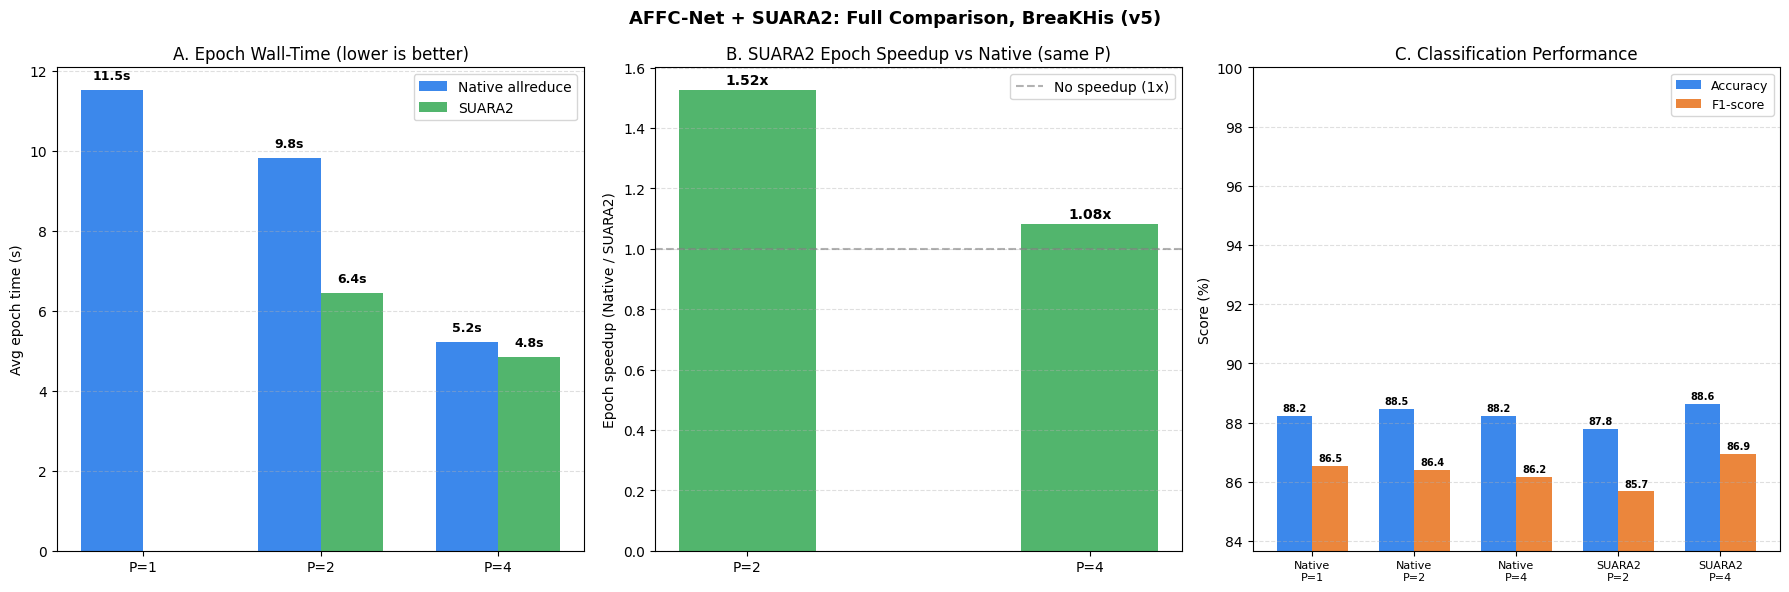

Saved -> /nfsshare/users/P126003189/breakhis_suara2_final_comparison_v5.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Chart A: Epoch wall-time
ax = axes[0]
p_vals = [1, 2, 4]
ep_nat = [results.get(f'native_P{p}', {}).get('avg_epoch_time') for p in p_vals]
ep_sua = [None] + [results.get(f'suara_P{p}', {}).get('avg_epoch_time') for p in [2, 4]]
x = np.arange(len(p_vals)); w = 0.35
b1 = ax.bar(x - w/2, [v if v else 0 for v in ep_nat], w,
            label='Native allreduce', color='#1a73e8', alpha=0.85)
b2 = ax.bar(x + w/2, [v if v else 0 for v in ep_sua], w,
            label='SUARA2', color='#34a853', alpha=0.85)
for bar, val in list(zip(b1, ep_nat)) + list(zip(b2, ep_sua)):
    if val:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val:.1f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([f'P={p}' for p in p_vals])
ax.set_ylabel('Avg epoch time (s)')
ax.set_title('A. Epoch Wall-Time (lower is better)')
ax.legend(); ax.grid(axis='y', ls='--', alpha=0.4)

# ── Chart B: Epoch speedup (SUARA2 vs Native, same P)
ax = axes[1]
p_comp = [2, 4]
ep_speedups = []
for p in p_comp:
    nat = results.get(f'native_P{p}', {}).get('avg_epoch_time')
    sua = results.get(f'suara_P{p}',  {}).get('avg_epoch_time')
    ep_speedups.append(nat / sua if nat and sua else 0)

x2 = np.arange(len(p_comp))
bars = ax.bar(x2, ep_speedups, color='#34a853', alpha=0.85, width=0.4)
ax.axhline(1.0, color='gray', ls='--', alpha=0.6, label='No speedup (1x)')
for bar, val in zip(bars, ep_speedups):
    if val:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}x', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(x2); ax.set_xticklabels([f'P={p}' for p in p_comp])
ax.set_ylabel('Epoch speedup (Native / SUARA2)')
ax.set_title('B. SUARA2 Epoch Speedup vs Native (same P)')
ax.legend(); ax.grid(axis='y', ls='--', alpha=0.4)

# ── Chart C: Classification metrics bar chart (Acc, F1)
ax = axes[2]
cfgs   = ['native_P1', 'native_P2', 'native_P4', 'suara_P2', 'suara_P4']
labels = ['Native\nP=1', 'Native\nP=2', 'Native\nP=4', 'SUARA2\nP=2', 'SUARA2\nP=4']
acc_vals = [results.get(c, {}).get('test_acc', 0) * 100 for c in cfgs]
f1_vals  = [results.get(c, {}).get('test_f1',  0) * 100 for c in cfgs]
x3 = np.arange(len(cfgs)); w3 = 0.35
ba = ax.bar(x3 - w3/2, acc_vals, w3, label='Accuracy', color='#1a73e8', alpha=0.85)
bf = ax.bar(x3 + w3/2, f1_vals,  w3, label='F1-score',  color='#e8711a', alpha=0.85)
for bar, val in list(zip(ba, acc_vals)) + list(zip(bf, f1_vals)):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.1f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
ax.set_xticks(x3); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Score (%)')
ax.set_title('C. Classification Performance')
ax.set_ylim([max(0, min(acc_vals + f1_vals) - 2) if any(acc_vals) else 0, 100])
ax.legend(fontsize=9); ax.grid(axis='y', ls='--', alpha=0.4)

plt.suptitle('AFFC-Net + SUARA2: Full Comparison, BreaKHis (v5)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(HOME, 'breakhis_suara2_final_comparison_v5.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'Saved -> {save_path}')

In [10]:
print('\n' + '=' * 72)
print('EXPERIMENT SUMMARY -- AFFC-Net + SUARA2 (v5) — BreaKHis')
print('=' * 72)

if 'native_P1' in results:
    r1 = results['native_P1']
    print('\nAFFC-Net Baseline (P=1, single GPU):')
    for mk, ml in zip(METRIC_KEYS, METRIC_LABELS):
        print(f'  {ml:<14}: {r1["test_" + mk]*100:.2f}%')
    print(f"  Epoch time  : {r1['avg_epoch_time']:.2f}s")
    if 'grad_bytes' in r1:
        print(f"  Grad buffer : {r1['grad_bytes']/1024:.1f} KB")

configs = [('native_P2','Native P=2'),('native_P4','Native P=4'),
           ('suara_P2', 'SUARA2 P=2'),('suara_P4', 'SUARA2 P=4')]
for cfg_key, cfg_label in configs:
    if cfg_key in results:
        r = results[cfg_key]
        print(f'\n{cfg_label}:')
        print(f"  F1={r['test_f1']*100:.2f}%  Acc={r['test_acc']*100:.2f}%  "
              f"epoch={r['avg_epoch_time']:.2f}s")

print('\n' + '-' * 72)
print('Epoch speedup (SUARA2 vs Native, same P):')
base_ep = results.get('native_P1', {}).get('avg_epoch_time')
for p in [2, 4]:
    nk = f'native_P{p}'; sk = f'suara_P{p}'
    if nk in results and sk in results:
        ep_sp = results[nk]['avg_epoch_time'] / results[sk]['avg_epoch_time']
        ep_vs_p1 = base_ep / results[sk]['avg_epoch_time'] if base_ep else None
        p1_str = f"  vs P=1 baseline: {ep_vs_p1:.2f}x" if ep_vs_p1 else ""
        print(f'  P={p}: Epoch speedup={ep_sp:.3f}x{p1_str}')

print('\n' + '-' * 72)
print('Allreduce speedup (SUARA2 vs Native, same P):')
for p in [2, 4]:
    nk = f'native_P{p}'; sk = f'suara_P{p}'
    if nk in results and sk in results:
        nat_ar = results[nk].get('avg_ar_time', 0)
        sua_ar = results[sk].get('avg_ar_time', 0)
        if nat_ar and sua_ar:
            ar_sp = nat_ar / sua_ar
            print(f'  P={p}: AR speedup={ar_sp:.3f}x  '
                  f'(native={nat_ar:.4f}s  suara={sua_ar:.4f}s)')
print('=' * 72)


EXPERIMENT SUMMARY -- AFFC-Net + SUARA2 (v5) — BreaKHis

AFFC-Net Baseline (P=1, single GPU):
  Acc           : 88.21%
  Prec          : 85.96%
  Rec           : 87.25%
  Spec          : 87.25%
  F1            : 86.55%
  Epoch time  : 11.51s
  Grad buffer : 7129.0 KB

Native P=2:
  F1=86.40%  Acc=88.46%  epoch=9.81s

Native P=4:
  F1=86.15%  Acc=88.21%  epoch=5.23s

SUARA2 P=2:
  F1=85.67%  Acc=87.78%  epoch=6.43s

SUARA2 P=4:
  F1=86.93%  Acc=88.63%  epoch=4.84s

------------------------------------------------------------------------
Epoch speedup (SUARA2 vs Native, same P):
  P=2: Epoch speedup=1.525x  vs P=1 baseline: 1.79x
  P=4: Epoch speedup=1.081x  vs P=1 baseline: 2.38x

------------------------------------------------------------------------
Allreduce speedup (SUARA2 vs Native, same P):
  P=2: AR speedup=201.078x  (native=7.6788s  suara=0.0382s)
  P=4: AR speedup=166.740x  (native=3.7542s  suara=0.0225s)


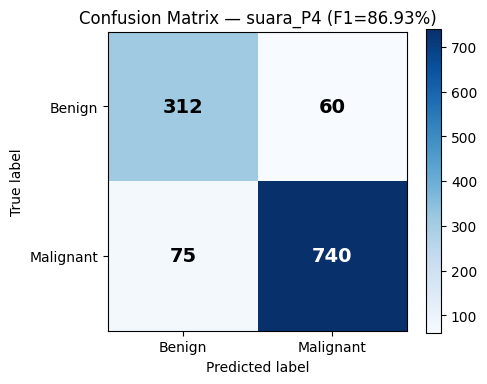

Confusion matrix saved -> /nfsshare/users/P126003189/breakhis_confusion_matrix_suara_P4_v5.png


In [11]:
# Confusion matrix visualisation for best available config
import matplotlib.patches as mpatches

best_key = None
best_f1  = 0.0
for key in ['suara_P4', 'suara_P2', 'native_P4', 'native_P2', 'native_P1']:
    if key in results and results[key].get('test_f1', 0) > best_f1:
        best_f1 = results[key]['test_f1']
        best_key = key

if best_key and 'test_cm' in results[best_key]:
    cm = np.array(results[best_key]['test_cm'])
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)
    classes = ['Benign', 'Malignant']
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(classes); ax.set_yticklabels(classes)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.set_title(f'Confusion Matrix — {best_key} (F1={best_f1*100:.2f}%)')
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]),
                    ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black',
                    fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_path = os.path.join(HOME, f'breakhis_confusion_matrix_{best_key}_v5.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'Confusion matrix saved -> {save_path}')
else:
    print('No results with confusion matrix found yet. Run training first.')